In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib import rcParams
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde
import foftools as fof
from center_binned_stats import center_binned_stats as cbs
if False:
    rcParams['axes.labelsize'] = 9
    rcParams['xtick.labelsize'] = 9
    rcParams['ytick.labelsize'] = 9
    rcParams['legend.fontsize'] = 9
    rcParams['font.family'] = 'sans-serif'
    rcParams['grid.color'] = 'k'
    rcParams['grid.linewidth'] = 0.2
my_locator = MaxNLocator(6)
singlecolsize = (3.3522420091324205, 2.0717995001590714)
doublecolsize = (7.100005949910059, 4.3880449973709)
cspeed=2.998e+5

In [2]:
# convert to Mpc using h=0.7
mocks=[]
for ii in range(0,8):
    mocks.append(pd.read_hdf("./halobiasmocks/fiducial/ECO_cat_{}_Planck_memb_cat.hdf5".format(ii)))
mock = pd.concat(mocks)
mock = mock[mock.cs_flag==1]
mock.loc[:,'loghalom']=mock['loghalom']-np.log10(0.7)
totalvolumemocks = (192351./(0.7**3))*len(mocks)

In [3]:
tinkerdata = np.genfromtxt('HaloMF337tinker.dat')
# work in h=0.7 Mpc
tinkermasses = tinkerdata[:,0]-np.log10(0.7)
tinkerfreq = tinkerdata[:,2]*(0.7**3)
tinkermf = (tinkermasses,tinkerfreq)

# Halo Mass Function (compare with Tinker)

10.475901959985743
10.569901959985742
10.499901959985744
10.499901959985744
10.514901959985743
10.483901959985744
10.475901959985743
10.542901959985743


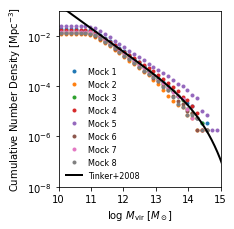

In [4]:
fig,ax1=plt.subplots(figsize=(singlecolsize[0],1.6*singlecolsize[1]))
binv=np.arange(10,15,0.15)
for ii in range(0,8):
    tmp = pd.read_hdf("./halobiasmocks/fiducial/ECO_cat_{}_Planck_memb_cat.hdf5".format(ii))
    mock = tmp[tmp.cs_flag==1]
    histval, binedges = np.histogram(mock.loghalom-np.log10(0.7), bins=binv)
    print(min(mock.loghalom-np.log10(0.7)))
    dens = len(mock)/1
    ax1.plot(0.5*(binedges[1:]+binedges[:-1]), (np.cumsum(histval[::-1])[::-1]) / (192351./(0.7**3)), '.', label='Mock {}'.format(1+ii))
ax1.plot(*tinkermf,'-',color='k', alpha=1, linewidth=2, label='Tinker+2008')
ax1.set_xlabel(r"log $M_{\rm vir}$ [$M_\odot$]")
ax1.set_ylabel(r"Cumulative Number Density [$\rm Mpc^{-3}$]")
ax1.set_yscale('log')
ax1.set_xlim(10,15)
plt.ylim(1e-8,1e-1)
plt.legend(loc='best',ncol=1,fontsize=8,framealpha=0)
plt.tight_layout()
plt.savefig("./figures/MFcomparison.pdf",dpi=300)
plt.show()

# Distributions in $R_{\rm proj}$ or $\Delta v_{\rm proj}$ vs. $\log M_{\rm halo}$ Space

In [5]:
H0value=70.
eco = pd.read_csv("../g3groups/ECOliving_071122.csv")
eco = eco[(eco.absrmag<-17.33)&(eco.grpcz<7000)&(eco.grpcz>3000)]
grpradeg,grpdedeg,grpcz = fof.group_skycoords(np.array(eco.radeg),np.array(eco.dedeg),np.array(eco.cz),np.array(eco.grp))
half_angle = fof.angular_separation(eco.radeg,eco.dedeg,grpradeg,grpdedeg)/2.
eco.loc[:,'ecorprojgal']=(eco.cz+grpcz)/H0value * np.sin(half_angle)
eco.loc[:,'ecovprojgal']=np.abs(eco.cz-grpcz)
#eco=eco[eco.grpn>1]
print(len(eco))

9455


In [6]:
mocks=[]
for ii in range(0,8): # mock with closest density is number 2
    tmp = pd.read_hdf("./halobiasmocks/fiducial/ECO_cat_{}_Planck_memb_cat.hdf5".format(ii))
    grpradeg,grpdedeg,grpcz = fof.group_skycoords(np.array(tmp.ra),np.array(tmp.dec),np.array(tmp.cz),np.array(tmp.groupid))
    half_angle = fof.angular_separation(tmp.ra, tmp.dec, grpradeg, grpdedeg)/2.
    tmp.loc[:,'mockrprojgal']=(tmp.cz+grpcz)/H0value * np.sin(half_angle)
    tmp.loc[:,'mockvprojgal']=np.abs(tmp.cz-grpcz)
    tmp = tmp[(tmp.M_r<-17.33)&(grpcz>3000)&(grpcz<7000)]#&(tmp.g_ngal>1)]
    mocks.append(tmp)
mock = pd.concat(mocks)
mock.loc[:,'M_group']=mock['M_group']-np.log10(H0value/100)
print(len(mock))
totalvolumemocks = (192351./(H0value/100.)**3.)*(len(mocks))

87495


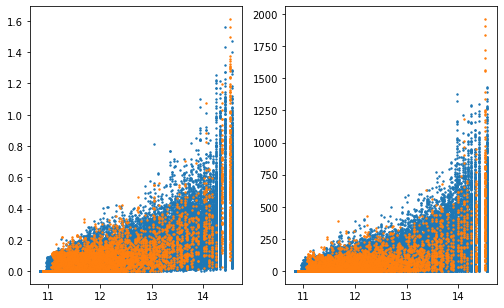

In [7]:
fig,(ax,ax1)=plt.subplots(ncols=2,figsize=doublecolsize)

ax.scatter(mock.M_group, mock.mockrprojgal,s=2)
ax.scatter(eco.logmh, eco.ecorprojgal,s=2)

ax1.scatter(mock.M_group, mock.mockvprojgal, s=2)
ax1.scatter(eco.logmh, eco.ecovprojgal, s=2)
plt.tight_layout()
plt.show()

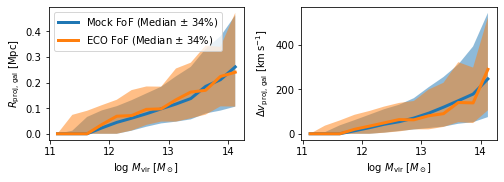

In [8]:
fig,(ax,ax1)=plt.subplots(ncols=2,figsize=(doublecolsize[0],0.6*doublecolsize[1]))
#fig,(ax,ax1)=plt.subplots(ncols=2,figsize=(9,4))
binv = np.arange(11,14.5,0.25)

medianmockrproj, medianmocklogmh, _, _ = cbs(mock.M_group, mock.mockrprojgal, 'median', bins=binv)
m1sigmockrproj, _, _, _ = cbs(mock.M_group, mock.mockrprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigmockrproj, _, _, _ = cbs(mock.M_group, mock.mockrprojgal, lambda x:np.percentile(x,84), bins=binv)

ax.plot(medianmocklogmh,medianmockrproj,linewidth=3, label=r'Mock FoF (Median $\pm$ 34%)')
ax.fill_between(medianmocklogmh, m1sigmockrproj, p1sigmockrproj,alpha=0.5)


medianecorproj, medianecologmh, _, _ = cbs(eco.logmh, eco.ecorprojgal, 'median', bins=binv)
m1sigecorproj, _, _, _ = cbs(eco.logmh, eco.ecorprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigecorproj, _, _, _ = cbs(eco.logmh, eco.ecorprojgal, lambda x:np.percentile(x,84), bins=binv)

ax.plot(medianecologmh,medianecorproj,linewidth=3, label=r'ECO FoF (Median $\pm$ 34%)')
ax.fill_between(medianecologmh, m1sigecorproj, p1sigecorproj,alpha=0.5)
ax.legend(loc='upper left')
ax.set_ylabel(r"$R_{\rm proj,\, gal}$ [Mpc]")
ax.set_xlabel(r"log $M_{\rm vir}$ [$M_\odot$]")

################################
################################

medianmockvproj, medianmocklogmh, _, _ = cbs(mock.M_group, mock.mockvprojgal, 'median', bins=binv)
m1sigmockvproj, _, _, _ = cbs(mock.M_group, mock.mockvprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigmockvproj, _, _, _ = cbs(mock.M_group, mock.mockvprojgal, lambda x:np.percentile(x,84), bins=binv)

ax1.plot(medianmocklogmh,medianmockvproj,linewidth=3, label=r'Mock FoF')
ax1.fill_between(medianmocklogmh, m1sigmockvproj, p1sigmockvproj,alpha=0.5)


medianecovproj, medianecologmh, _, _ = cbs(eco.logmh, eco.ecovprojgal, 'median', bins=binv)
m1sigecovproj, _, _, _ = cbs(eco.logmh, eco.ecovprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigecovproj, _, _, _ = cbs(eco.logmh, eco.ecovprojgal, lambda x:np.percentile(x,84), bins=binv)

ax1.plot(medianecologmh,medianecovproj,linewidth=3, label=r'ECO FoF')
ax1.fill_between(medianecologmh, m1sigecovproj, p1sigecovproj,alpha=0.5)
#ax1.legend(loc='upper left')
ax1.set_ylabel(r"$\Delta v_{\rm proj,\, gal}$ [$\rm km\, s^{-1}$]")
ax1.set_xlabel(r"log $M_{\rm vir}$ [$M_\odot$]")
plt.tight_layout()
plt.savefig("./figures/fofrprojvprojdists.pdf",dpi=300)
plt.show()

In [9]:
np.sum([eco.logmh<11.5])

5047

# testing other distribution stuff

In [10]:
H0value=100.
eco = pd.read_csv("../g3groups/ECOliving_071122.csv")
eco = eco[(eco.absrmag<-17.33)&(eco.grpcz<7000)&(eco.grpcz>3000)]
grpradeg,grpdedeg,grpcz = fof.group_skycoords(np.array(eco.radeg),np.array(eco.dedeg),np.array(eco.cz),np.array(eco.grp))
half_angle = fof.angular_separation(eco.radeg,eco.dedeg,grpradeg,grpdedeg)/2.
eco.loc[:,'ecorprojgal']=(eco.cz+grpcz)/H0value * np.sin(half_angle)
eco.loc[:,'ecovprojgal']=(eco.cz-grpcz)
eco.loc[:,'logmh']=eco.logmh + np.log10(0.7)
eco=eco[eco.grpn>1]
print(len(eco))

4171


In [11]:
mocks=[]
for ii in range(0,8): # mock with closest density is number 2
    tmp = pd.read_hdf("./halobiasmocks/fiducial/ECO_cat_{}_Planck_memb_cat.hdf5".format(ii))
    grpradeg,grpdedeg,grpcz = fof.group_skycoords(np.array(tmp.ra),np.array(tmp.dec),np.array(tmp.cz),np.array(tmp.haloid))
    half_angle = fof.angular_separation(tmp.ra, tmp.dec, grpradeg, grpdedeg)/2.
    tmp.loc[:,'mockrprojgal']=(tmp.cz+grpcz)/H0value * np.sin(half_angle)
    tmp.loc[:,'mockvprojgal']=(tmp.cz-grpcz)
    tmp = tmp[(tmp.M_r<-17.33)&(grpcz>3000)&(grpcz<7000)&(tmp.halo_ngal>1)]
    mocks.append(tmp)
    print(ii,len(eco)-len(tmp))
mock = pd.concat(mocks)
print(len(mock))
totalvolumemocks = 192351.*len(mocks)

0 -2068
1 1036
2 -884
3 -2353
4 -7606
5 -149
6 -686
7 -9
46087


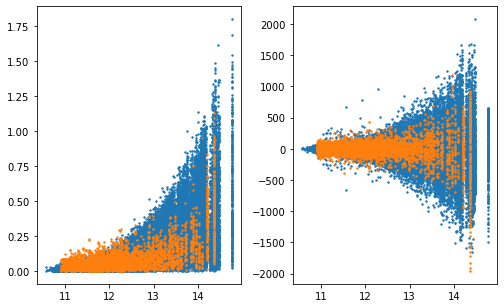

In [12]:
fig,(ax,ax1)=plt.subplots(ncols=2,figsize=doublecolsize)

ax.scatter(mock.loghalom, mock.mockrprojgal,s=2)
ax.scatter(eco.logmh, eco.ecorprojgal,s=2)

ax1.scatter(mock.loghalom, mock.mockvprojgal, s=2)
ax1.scatter(eco.logmh, eco.ecovprojgal, s=2)
plt.tight_layout()
plt.show()

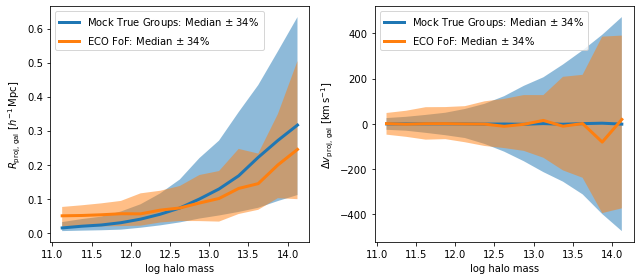

In [13]:
#fig,(ax,ax1)=plt.subplots(ncols=2,figsize=doublecolsize)
fig,(ax,ax1)=plt.subplots(ncols=2,figsize=(9,4))
binv = np.arange(11,14.5,0.25)

medianmockrproj, medianmocklogmh, _, _ = cbs(mock.loghalom, mock.mockrprojgal, 'median', bins=binv)
m1sigmockrproj, _, _, _ = cbs(mock.loghalom, mock.mockrprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigmockrproj, _, _, _ = cbs(mock.loghalom, mock.mockrprojgal, lambda x:np.percentile(x,84), bins=binv)

ax.plot(medianmocklogmh,medianmockrproj,linewidth=3, label=r'Mock True Groups: Median $\pm$ 34%')
ax.fill_between(medianmocklogmh, m1sigmockrproj, p1sigmockrproj,alpha=0.5)


medianecorproj, medianecologmh, _, _ = cbs(eco.logmh, eco.ecorprojgal, 'median', bins=binv)
m1sigecorproj, _, _, _ = cbs(eco.logmh, eco.ecorprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigecorproj, _, _, _ = cbs(eco.logmh, eco.ecorprojgal, lambda x:np.percentile(x,84), bins=binv)

ax.plot(medianecologmh,medianecorproj,linewidth=3, label=r'ECO FoF: Median $\pm$ 34%')
ax.fill_between(medianecologmh, m1sigecorproj, p1sigecorproj,alpha=0.5)
ax.legend(loc='upper left')
ax.set_ylabel(r"$R_{\rm proj,\, gal}$ [$h^{-1}\rm\, Mpc$]")
ax.set_xlabel("log halo mass")

################################
################################

medianmockvproj, medianmocklogmh, _, _ = cbs(mock.loghalom, mock.mockvprojgal, 'median', bins=binv)
m1sigmockvproj, _, _, _ = cbs(mock.loghalom, mock.mockvprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigmockvproj, _, _, _ = cbs(mock.loghalom, mock.mockvprojgal, lambda x:np.percentile(x,84), bins=binv)

ax1.plot(medianmocklogmh,medianmockvproj,linewidth=3, label=r'Mock True Groups: Median $\pm$ 34%')
ax1.fill_between(medianmocklogmh, m1sigmockvproj, p1sigmockvproj,alpha=0.5)


medianecovproj, medianecologmh, _, _ = cbs(eco.logmh, eco.ecovprojgal, 'median', bins=binv)
m1sigecovproj, _, _, _ = cbs(eco.logmh, eco.ecovprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigecovproj, _, _, _ = cbs(eco.logmh, eco.ecovprojgal, lambda x:np.percentile(x,84), bins=binv)

ax1.plot(medianecologmh,medianecovproj,linewidth=3, label=r'ECO FoF: Median $\pm$ 34%')
ax1.fill_between(medianecologmh, m1sigecovproj, p1sigecovproj,alpha=0.5)
ax1.legend(loc='upper left')
ax1.set_ylabel(r"$\Delta v_{\rm proj,\, gal}$ [$\rm km\, s^{-1}$]")
ax1.set_xlabel("log halo mass")

plt.tight_layout()
plt.show()

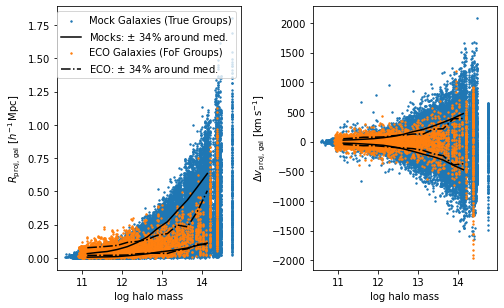

In [14]:
fig,(ax,ax1)=plt.subplots(ncols=2,figsize=doublecolsize)

medianmockrproj, medianmocklogmh, _, _ = cbs(mock.loghalom, mock.mockrprojgal, 'median', bins=binv)
m1sigmockrproj, _, _, _ = cbs(mock.loghalom, mock.mockrprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigmockrproj, _, _, _ = cbs(mock.loghalom, mock.mockrprojgal, lambda x:np.percentile(x,84), bins=binv)
ax.scatter(mock.loghalom, mock.mockrprojgal,s=2, label='Mock Galaxies (True Groups)')
ax.plot(medianmocklogmh,p1sigmockrproj,color='k',label=r'Mocks: $\pm$ 34% around med.')
ax.plot(medianmocklogmh,m1sigmockrproj,color='k')
#ax.plot(medianmocklogmh,medianmockrproj,color='k')

medianecorproj, medianecologmh, _, _ = cbs(eco.logmh, eco.ecorprojgal, 'median', bins=binv)
m1sigecorproj, _, _, _ = cbs(eco.logmh, eco.ecorprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigecorproj, _, _, _ = cbs(eco.logmh, eco.ecorprojgal, lambda x:np.percentile(x,84), bins=binv)
ax.scatter(eco.logmh, eco.ecorprojgal,s=2, label='ECO Galaxies (FoF Groups)')
ax.plot(medianecologmh,p1sigecorproj,color='k', linestyle='-.', label=r'ECO: $\pm$ 34% around med.')
#ax.plot(medianecologmh,medianecorproj,color='k',linestyle='-.')
ax.plot(medianecologmh,m1sigecorproj,color='k', linestyle='-.')

ax.set_ylabel(r"$R_{\rm proj,\, gal}$ [$h^{-1}\rm\, Mpc$]")
ax.set_xlabel("log halo mass")

###########

medianmockvproj, medianmocklogmh, _, _ = cbs(mock.loghalom, mock.mockvprojgal, 'median', bins=binv)
m1sigmockvproj, _, _, _ = cbs(mock.loghalom, mock.mockvprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigmockvproj, _, _, _ = cbs(mock.loghalom, mock.mockvprojgal, lambda x:np.percentile(x,84), bins=binv)
ax1.scatter(mock.loghalom, mock.mockvprojgal,s=2)
ax1.plot(medianmocklogmh,p1sigmockvproj,color='k',label=r'Mocks: Median $\pm$ 34%')
ax1.plot(medianmocklogmh,m1sigmockvproj,color='k')

medianecovproj, medianecologmh, _, _ = cbs(eco.logmh, eco.ecovprojgal, 'median', bins=binv)
m1sigecovproj, _, _, _ = cbs(eco.logmh, eco.ecovprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigecovproj, _, _, _ = cbs(eco.logmh, eco.ecovprojgal, lambda x:np.percentile(x,84), bins=binv)
ax1.scatter(eco.logmh, eco.ecovprojgal,s=2)
ax1.plot(medianecologmh,p1sigecovproj,color='k', linestyle='-.', label=r'ECO: $\pm$ 34% around median')
ax1.plot(medianecologmh,m1sigecovproj,color='k', linestyle='-.')

ax1.set_ylabel(r"$\Delta v_{\rm proj,\, gal}$ [$\rm km\, s^{-1}$]")
ax1.set_xlabel("log halo mass")

ax.legend(loc='best')
plt.tight_layout()
plt.show()

## manually checking percentile bands

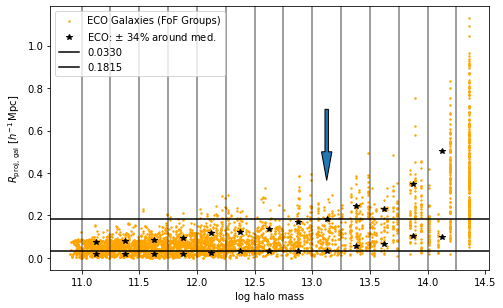

In [15]:
fig,ax=plt.subplots(ncols=1,figsize=doublecolsize)

# medianmockrproj, medianmocklogmh, _, _ = cbs(mock.loghalom, mock.mockrprojgal, 'median', bins=binv)
# m1sigmockrproj, _, _, _ = cbs(mock.loghalom, mock.mockrprojgal, lambda x:np.percentile(x,16), bins=binv)
# p1sigmockrproj, _, _, _ = cbs(mock.loghalom, mock.mockrprojgal, lambda x:np.percentile(x,84), bins=binv)
# ax.scatter(mock.loghalom, mock.mockrprojgal,s=2, label='Mock Galaxies (True Groups)')
# ax.plot(medianmocklogmh,p1sigmockrproj,color='k',label=r'Mocks: $\pm$ 34% around med.')
# ax.plot(medianmocklogmh,m1sigmockrproj,color='k')
#ax.plot(medianmocklogmh,medianmockrproj,color='k')

medianecorproj, medianecologmh, edges, _ = cbs(eco.logmh, eco.ecorprojgal, 'median', bins=binv)
m1sigecorproj, _, _, _ = cbs(eco.logmh, eco.ecorprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigecorproj, _, _, _ = cbs(eco.logmh, eco.ecorprojgal, lambda x:np.percentile(x,84), bins=binv)
ax.scatter(eco.logmh, eco.ecorprojgal,s=2, label='ECO Galaxies (FoF Groups)', color='orange')
ax.plot(medianecologmh,p1sigecorproj,'k*', label=r'ECO: $\pm$ 34% around med.')
#ax.plot(medianecologmh,medianecorproj,color='k',linestyle='-.')
ax.plot(medianecologmh,m1sigecorproj,'k*')
for ee in edges: ax.axvline(ee, color='k', alpha=0.5)
ax.axhline(0.0330,color='k',label='0.0330')
ax.axhline(0.18147912867594038,color='k',label='0.1815')
ax.arrow(13.125,0.7,0,-0.2,width=0.03)
ax.set_ylabel(r"$R_{\rm proj,\, gal}$ [$h^{-1}\rm\, Mpc$]")
ax.set_xlabel("log halo mass")

###########

# medianmockvproj, medianmocklogmh, _, _ = cbs(mock.loghalom, mock.mockvprojgal, 'median', bins=binv)
# m1sigmockvproj, _, _, _ = cbs(mock.loghalom, mock.mockvprojgal, lambda x:np.percentile(x,16), bins=binv)
# p1sigmockvproj, _, _, _ = cbs(mock.loghalom, mock.mockvprojgal, lambda x:np.percentile(x,84), bins=binv)
# ax1.scatter(mock.loghalom, mock.mockvprojgal,s=2)
# ax1.plot(medianmocklogmh,p1sigmockvproj,color='k',label=r'Mocks: Median $\pm$ 34%')
# ax1.plot(medianmocklogmh,m1sigmockvproj,color='k')

# medianecovproj, medianecologmh, _, _ = cbs(eco.logmh, eco.ecovprojgal, 'median', bins=binv)
# m1sigecovproj, _, _, _ = cbs(eco.logmh, eco.ecovprojgal, lambda x:np.percentile(x,16), bins=binv)
# p1sigecovproj, _, _, _ = cbs(eco.logmh, eco.ecovprojgal, lambda x:np.percentile(x,84), bins=binv)
# ax1.scatter(eco.logmh, eco.ecovprojgal,s=2)
# ax1.plot(medianecologmh,p1sigecovproj,color='k', linestyle='-.', label=r'ECO: $\pm$ 34% around median')
# ax1.plot(medianecologmh,m1sigecovproj,color='k', linestyle='-.')

# ax1.set_ylabel(r"$\Delta v_{\rm proj,\, gal}$ [$\rm km\, s^{-1}$]")
ax1.set_xlabel("log halo mass")

ax.legend(loc='best')
plt.tight_layout()
plt.show()

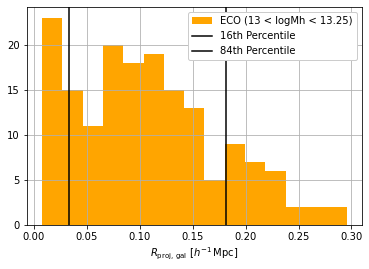

167
0.03298590163458725 0.18147912867594038
0.16167664670658682
0.16167664670658682


In [16]:
sel = (eco.logmh>13.0)&(eco.logmh<13.25)
plt.figure()
histv,bv,_=plt.hist(eco[sel].ecorprojgal, bins=15, color='orange', label='ECO (13 < logMh < 13.25)')
plt.axvline(np.percentile(eco[sel].ecorprojgal,16),color='k', label='16th Percentile')
plt.axvline(np.percentile(eco[sel].ecorprojgal,84),color='k', label='84th Percentile')
plt.xlabel(r"$R_{\rm proj,\, gal}$ [$h^{-1}\rm\, Mpc$]")
plt.legend(loc='best',framealpha=1)
plt.grid()
plt.show()
print(len(eco[sel]))


print(np.percentile(eco[sel].ecorprojgal,16), np.percentile(eco[sel].ecorprojgal,84))
print(np.sum(eco[sel].ecorprojgal>0.181479)/len(eco[sel]))
print(np.sum(eco[sel].ecorprojgal<0.032985901)/len(eco[sel]))

In [17]:
bv

array([0.00777359, 0.02694332, 0.04611304, 0.06528277, 0.08445249,
       0.10362222, 0.12279194, 0.14196167, 0.16113139, 0.18030112,
       0.19947084, 0.21864057, 0.23781029, 0.25698002, 0.27614974,
       0.29531946])

In [18]:
bv = (bv[1:]+bv[:-1])/2.
sel = (bv>0.181)
bv[sel],histv[sel]

(array([0.18988598, 0.2090557 , 0.22822543, 0.24739515, 0.26656488,
        0.2857346 ]),
 array([9., 7., 6., 2., 2., 2.]))

In [19]:
sel = (bv<0.033)
bv[sel],histv[sel]

(array([0.01735846]), array([23.]))

In [20]:
30/167

0.17964071856287425

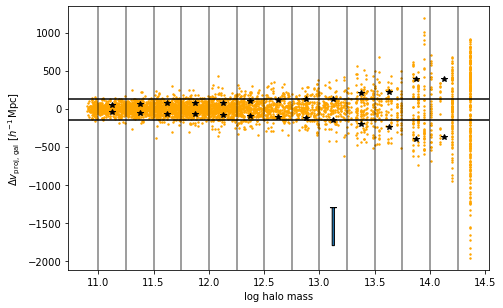

In [21]:
fig,ax1=plt.subplots(ncols=1,figsize=doublecolsize)

# medianmockrproj, medianmocklogmh, _, _ = cbs(mock.loghalom, mock.mockrprojgal, 'median', bins=binv)
# m1sigmockrproj, _, _, _ = cbs(mock.loghalom, mock.mockrprojgal, lambda x:np.percentile(x,16), bins=binv)
# p1sigmockrproj, _, _, _ = cbs(mock.loghalom, mock.mockrprojgal, lambda x:np.percentile(x,84), bins=binv)
# ax.scatter(mock.loghalom, mock.mockrprojgal,s=2, label='Mock Galaxies (True Groups)')
# ax.plot(medianmocklogmh,p1sigmockrproj,color='k',label=r'Mocks: $\pm$ 34% around med.')
# ax.plot(medianmocklogmh,m1sigmockrproj,color='k')
#ax.plot(medianmocklogmh,medianmockrproj,color='k')

# medianecorproj, medianecologmh, edges, _ = cbs(eco.logmh, eco.ecorprojgal, 'median', bins=binv)
# m1sigecorproj, _, _, _ = cbs(eco.logmh, eco.ecorprojgal, lambda x:np.percentile(x,16), bins=binv)
# p1sigecorproj, _, _, _ = cbs(eco.logmh, eco.ecorprojgal, lambda x:np.percentile(x,84), bins=binv)
# ax.scatter(eco.logmh, eco.ecorprojgal,s=2, label='ECO Galaxies (FoF Groups)', color='orange')
# ax.plot(medianecologmh,p1sigecorproj,'k*', label=r'ECO: $\pm$ 34% around med.')
# #ax.plot(medianecologmh,medianecorproj,color='k',linestyle='-.')
# ax.plot(medianecologmh,m1sigecorproj,'k*')
# for ee in edges: ax.axvline(ee, color='k', alpha=0.5)
# ax.axhline(0.0330,color='k',label='0.0330')
# ax.axhline(0.18147912867594038,color='k',label='0.1815')
# ax.arrow(13.125,0.7,0,-0.2,width=0.03)
# ax.set_ylabel(r"$R_{\rm proj,\, gal}$ [$h^{-1}\rm\, Mpc$]")
# ax.set_xlabel("log halo mass")

###########

# medianmockvproj, medianmocklogmh, _, _ = cbs(mock.loghalom, mock.mockvprojgal, 'median', bins=binv)
# m1sigmockvproj, _, _, _ = cbs(mock.loghalom, mock.mockvprojgal, lambda x:np.percentile(x,16), bins=binv)
# p1sigmockvproj, _, _, _ = cbs(mock.loghalom, mock.mockvprojgal, lambda x:np.percentile(x,84), bins=binv)
# ax1.scatter(mock.loghalom, mock.mockvprojgal,s=2)
# ax1.plot(medianmocklogmh,p1sigmockvproj,color='k',label=r'Mocks: Median $\pm$ 34%')
# ax1.plot(medianmocklogmh,m1sigmockvproj,color='k')

medianecovproj, medianecologmh, _, _ = cbs(eco.logmh, eco.ecovprojgal, 'median', bins=binv)
m1sigecovproj, _, _, _ = cbs(eco.logmh, eco.ecovprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigecovproj, _, _, _ = cbs(eco.logmh, eco.ecovprojgal, lambda x:np.percentile(x,84), bins=binv)
ax1.scatter(eco.logmh, eco.ecovprojgal,s=2, color='orange')
ax1.plot(medianecologmh,p1sigecovproj,'k*', label=r'ECO: $\pm$ 34% around median')
ax1.plot(medianecologmh,m1sigecovproj,'k*')
for ee in edges: ax1.axvline(ee, color='k', alpha=0.5)
ax1.arrow(13.125,-1800,0,500,width=0.02)
# ax1.set_ylabel(r"$\Delta v_{\rm proj,\, gal}$ [$\rm km\, s^{-1}$]")
ax1.set_xlabel("log halo mass")
ax1.set_ylabel(r"$\Delta v_{\rm proj,\, gal}$ [$h^{-1}\rm\, Mpc$]")
ax1.axhline(-149.7045152377737,color='k')
ax1.axhline(127.15264214210364,color='k')

ax.legend(loc='best')
plt.tight_layout()
plt.show()

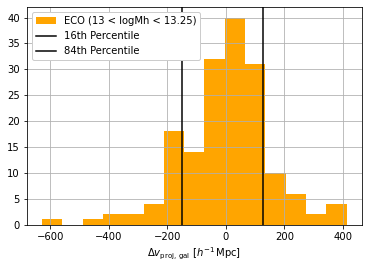

167
-149.7045152377737 127.15264214210364
0.16167664670658682
0.16167664670658682


In [22]:
sel = (eco.logmh>13.0)&(eco.logmh<13.25)
plt.figure()
histv,bv,_=plt.hist(eco[sel].ecovprojgal, bins=15, color='orange', label='ECO (13 < logMh < 13.25)')
plt.axvline(np.percentile(eco[sel].ecovprojgal,16),color='k', label='16th Percentile')
plt.axvline(np.percentile(eco[sel].ecovprojgal,84),color='k', label='84th Percentile')
plt.xlabel(r"$\Delta v_{\rm proj,\, gal}$ [$h^{-1}\rm\, Mpc$]")
plt.legend(loc='best',framealpha=1)
plt.grid()
plt.show()
print(len(eco[sel]))


print(np.percentile(eco[sel].ecovprojgal,16), np.percentile(eco[sel].ecovprojgal,84))
print(np.sum(eco[sel].ecovprojgal>127.153)/len(eco[sel]))
print(np.sum(eco[sel].ecovprojgal<-149.70452)/len(eco[sel]))

In [23]:
bv = (bv[1:]+bv[:-1])/2.
sel = (bv>127.152)
bv[sel],histv[sel],np.sum(histv[sel])/167

(array([169.3487224, 238.6893178, 308.0299132, 377.3705086]),
 array([10.,  6.,  2.,  4.]),
 0.1317365269461078)

In [24]:
sel = (bv<-149.7045)
bv[sel],histv[sel],np.sum(histv[sel])/167

(array([-593.397827 , -524.0572316, -454.7166362, -385.3760408,
        -316.0354454, -246.69485  , -177.3542546]),
 array([ 1.,  0.,  1.,  2.,  2.,  4., 18.]),
 0.16766467065868262)

# do mock FoF groups show the same $R_{\rm proj} - \log M_{\rm halo}$ relation?

In [25]:
H0value=100.
mocks=[]
for ii in range(2,3): # mock with closest density is number 2
    tmp = pd.read_hdf("./halobiasmocks/fiducial/ECO_cat_{}_Planck_memb_cat.hdf5".format(ii))
    grpradeg,grpdedeg,grpcz = fof.group_skycoords(np.array(tmp.ra),np.array(tmp.dec),np.array(tmp.cz),np.array(tmp.haloid))
    half_angle = fof.angular_separation(tmp.ra, tmp.dec, grpradeg, grpdedeg)/2.
    tmp.loc[:,'mockrprojgal']=(tmp.cz+grpcz)/H0value * np.sin(half_angle)
    tmp.loc[:,'mockvprojgal']=(tmp.cz-grpcz)
    #tmp = tmp[(tmp.M_r<-17.33)&(grpcz>3000)&(grpcz<7000)&(tmp.halo_ngal>1)]
    mocks.append(tmp)
mock = pd.concat(mocks)
print(len(mock))
totalvolumemocks = 192351.*len(mocks)

12891


In [26]:
H0value=100.
eco = pd.read_hdf("./halobiasmocks/fiducial/ECO_cat_2_Planck_memb_cat.hdf5")
grpradeg,grpdedeg,grpcz = fof.group_skycoords(np.array(eco.ra),np.array(eco.dec),np.array(eco.cz),np.array(eco.groupid))
half_angle = fof.angular_separation(eco.ra,eco.dec,grpradeg,grpdedeg)/2.
eco.loc[:,'ecorprojgal']=(eco.cz+grpcz)/H0value * np.sin(half_angle)
eco.loc[:,'ecovprojgal']=(eco.cz-grpcz)
eco.loc[:,'logmh']=eco.M_group + np.log10(0.7)
#eco = eco[(eco.M_r<-17.33)&(grpcz<7000)&(grpcz>3000)]
eco=eco[eco.g_ngal>1]
print(len(eco))

6813


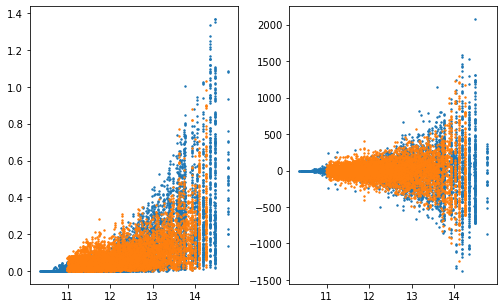

In [27]:
fig,(ax,ax1)=plt.subplots(ncols=2,figsize=doublecolsize)

ax.scatter(mock.loghalom, mock.mockrprojgal,s=2)
ax.scatter(eco.logmh, eco.ecorprojgal,s=2)

ax1.scatter(mock.loghalom, mock.mockvprojgal, s=2)
ax1.scatter(eco.logmh, eco.ecovprojgal, s=2)
plt.tight_layout()
plt.show()

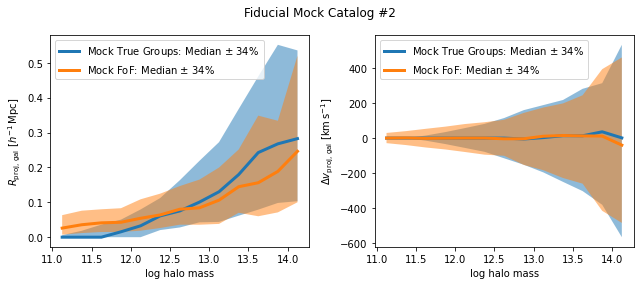

In [28]:
#fig,(ax,ax1)=plt.subplots(ncols=2,figsize=doublecolsize)
fig,(ax,ax1)=plt.subplots(ncols=2,figsize=(9,4))
binv = np.arange(11,14.5,0.25)

medianmockrproj, medianmocklogmh, _, _ = cbs(mock.loghalom, mock.mockrprojgal, 'median', bins=binv)
m1sigmockrproj, _, _, _ = cbs(mock.loghalom, mock.mockrprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigmockrproj, _, _, _ = cbs(mock.loghalom, mock.mockrprojgal, lambda x:np.percentile(x,84), bins=binv)

ax.plot(medianmocklogmh,medianmockrproj,linewidth=3, label=r'Mock True Groups: Median $\pm$ 34%')
ax.fill_between(medianmocklogmh, m1sigmockrproj, p1sigmockrproj,alpha=0.5)


medianecorproj, medianecologmh, _, _ = cbs(eco.logmh, eco.ecorprojgal, 'median', bins=binv)
m1sigecorproj, _, _, _ = cbs(eco.logmh, eco.ecorprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigecorproj, _, _, _ = cbs(eco.logmh, eco.ecorprojgal, lambda x:np.percentile(x,84), bins=binv)

ax.plot(medianecologmh,medianecorproj,linewidth=3, label=r'Mock FoF: Median $\pm$ 34%')
ax.fill_between(medianecologmh, m1sigecorproj, p1sigecorproj,alpha=0.5)
ax.legend(loc='upper left')
ax.set_ylabel(r"$R_{\rm proj,\, gal}$ [$h^{-1}\rm\, Mpc$]")
ax.set_xlabel("log halo mass")

################################
################################

medianmockvproj, medianmocklogmh, _, _ = cbs(mock.loghalom, mock.mockvprojgal, 'median', bins=binv)
m1sigmockvproj, _, _, _ = cbs(mock.loghalom, mock.mockvprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigmockvproj, _, _, _ = cbs(mock.loghalom, mock.mockvprojgal, lambda x:np.percentile(x,84), bins=binv)

ax1.plot(medianmocklogmh,medianmockvproj,linewidth=3, label=r'Mock True Groups: Median $\pm$ 34%')
ax1.fill_between(medianmocklogmh, m1sigmockvproj, p1sigmockvproj,alpha=0.5)


medianecovproj, medianecologmh, _, _ = cbs(eco.logmh, eco.ecovprojgal, 'median', bins=binv)
m1sigecovproj, _, _, _ = cbs(eco.logmh, eco.ecovprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigecovproj, _, _, _ = cbs(eco.logmh, eco.ecovprojgal, lambda x:np.percentile(x,84), bins=binv)

ax1.plot(medianecologmh,medianecovproj,linewidth=3, label=r'Mock FoF: Median $\pm$ 34%')
ax1.fill_between(medianecologmh, m1sigecovproj, p1sigecovproj,alpha=0.5)
ax1.legend(loc='upper left')
ax1.set_ylabel(r"$\Delta v_{\rm proj,\, gal}$ [$\rm km\, s^{-1}$]")
ax1.set_xlabel("log halo mass")

plt.suptitle("Fiducial Mock Catalog #2")
plt.tight_layout()
plt.show()

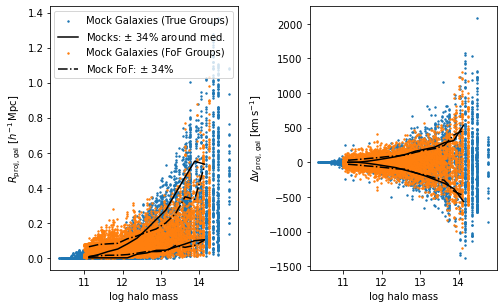

In [29]:
fig,(ax,ax1)=plt.subplots(ncols=2,figsize=doublecolsize)

medianmockrproj, medianmocklogmh, _, _ = cbs(mock.loghalom, mock.mockrprojgal, 'median', bins=binv)
m1sigmockrproj, _, _, _ = cbs(mock.loghalom, mock.mockrprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigmockrproj, _, _, _ = cbs(mock.loghalom, mock.mockrprojgal, lambda x:np.percentile(x,84), bins=binv)
ax.scatter(mock.loghalom, mock.mockrprojgal,s=2, label='Mock Galaxies (True Groups)')
ax.plot(medianmocklogmh,p1sigmockrproj,color='k',label=r'Mocks: $\pm$ 34% around med.')
ax.plot(medianmocklogmh,m1sigmockrproj,color='k')
#ax.plot(medianmocklogmh,medianmockrproj,color='k')

medianecorproj, medianecologmh, _, _ = cbs(eco.logmh, eco.ecorprojgal, 'median', bins=binv)
m1sigecorproj, _, _, _ = cbs(eco.logmh, eco.ecorprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigecorproj, _, _, _ = cbs(eco.logmh, eco.ecorprojgal, lambda x:np.percentile(x,84), bins=binv)
ax.scatter(eco.logmh, eco.ecorprojgal,s=2, label='Mock Galaxies (FoF Groups)')
ax.plot(medianecologmh,p1sigecorproj,color='k', linestyle='-.', label=r'Mock FoF: $\pm$ 34%')
#ax.plot(medianecologmh,medianecorproj,color='k',linestyle='-.')
ax.plot(medianecologmh,m1sigecorproj,color='k', linestyle='-.')

ax.set_ylabel(r"$R_{\rm proj,\, gal}$ [$h^{-1}\rm\, Mpc$]")
ax.set_xlabel("log halo mass")

###########

medianmockvproj, medianmocklogmh, _, _ = cbs(mock.loghalom, mock.mockvprojgal, 'median', bins=binv)
m1sigmockvproj, _, _, _ = cbs(mock.loghalom, mock.mockvprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigmockvproj, _, _, _ = cbs(mock.loghalom, mock.mockvprojgal, lambda x:np.percentile(x,84), bins=binv)
ax1.scatter(mock.loghalom, mock.mockvprojgal,s=2)
ax1.plot(medianmocklogmh,p1sigmockvproj,color='k',label=r'Mocks: Median $\pm$ 34%')
ax1.plot(medianmocklogmh,m1sigmockvproj,color='k')

medianecovproj, medianecologmh, _, _ = cbs(eco.logmh, eco.ecovprojgal, 'median', bins=binv)
m1sigecovproj, _, _, _ = cbs(eco.logmh, eco.ecovprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigecovproj, _, _, _ = cbs(eco.logmh, eco.ecovprojgal, lambda x:np.percentile(x,84), bins=binv)
ax1.scatter(eco.logmh, eco.ecovprojgal,s=2)
ax1.plot(medianecologmh,p1sigecovproj,color='k', linestyle='-.', label=r'Mock FoF: $\pm$ 34%')
ax1.plot(medianecologmh,m1sigecovproj,color='k', linestyle='-.')

ax1.set_ylabel(r"$\Delta v_{\rm proj,\, gal}$ [$\rm km\, s^{-1}$]")
ax1.set_xlabel("log halo mass")

ax.legend(loc='best')
plt.tight_layout()
plt.show()

### looking at specific test case

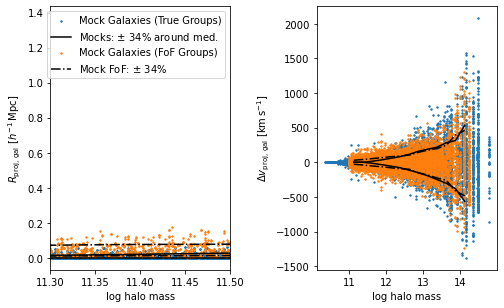

In [30]:
fig,(ax,ax1)=plt.subplots(ncols=2,figsize=doublecolsize)

medianmockrproj, medianmocklogmh, _, _ = cbs(mock.loghalom, mock.mockrprojgal, 'median', bins=binv)
m1sigmockrproj, _, _, _ = cbs(mock.loghalom, mock.mockrprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigmockrproj, _, _, _ = cbs(mock.loghalom, mock.mockrprojgal, lambda x:np.percentile(x,84), bins=binv)
ax.scatter(mock.loghalom, mock.mockrprojgal,s=2, label='Mock Galaxies (True Groups)')
ax.plot(medianmocklogmh,p1sigmockrproj,color='k',label=r'Mocks: $\pm$ 34% around med.')
ax.plot(medianmocklogmh,m1sigmockrproj,color='k')
#ax.plot(medianmocklogmh,medianmockrproj,color='k')

medianecorproj, medianecologmh, _, _ = cbs(eco.logmh, eco.ecorprojgal, 'median', bins=binv)
m1sigecorproj, _, _, _ = cbs(eco.logmh, eco.ecorprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigecorproj, _, _, _ = cbs(eco.logmh, eco.ecorprojgal, lambda x:np.percentile(x,84), bins=binv)
ax.scatter(eco.logmh, eco.ecorprojgal,s=2, label='Mock Galaxies (FoF Groups)')
ax.plot(medianecologmh,p1sigecorproj,color='k', linestyle='-.', label=r'Mock FoF: $\pm$ 34%')
#ax.plot(medianecologmh,medianecorproj,color='k',linestyle='-.')
ax.plot(medianecologmh,m1sigecorproj,color='k', linestyle='-.')

ax.set_ylabel(r"$R_{\rm proj,\, gal}$ [$h^{-1}\rm\, Mpc$]")
ax.set_xlabel("log halo mass")
ax.set_xlim(11.3,11.5)

###########

medianmockvproj, medianmocklogmh, _, _ = cbs(mock.loghalom, mock.mockvprojgal, 'median', bins=binv)
m1sigmockvproj, _, _, _ = cbs(mock.loghalom, mock.mockvprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigmockvproj, _, _, _ = cbs(mock.loghalom, mock.mockvprojgal, lambda x:np.percentile(x,84), bins=binv)
ax1.scatter(mock.loghalom, mock.mockvprojgal,s=2)
ax1.plot(medianmocklogmh,p1sigmockvproj,color='k',label=r'Mocks: Median $\pm$ 34%')
ax1.plot(medianmocklogmh,m1sigmockvproj,color='k')

medianecovproj, medianecologmh, _, _ = cbs(eco.logmh, eco.ecovprojgal, 'median', bins=binv)
m1sigecovproj, _, _, _ = cbs(eco.logmh, eco.ecovprojgal, lambda x:np.percentile(x,16), bins=binv)
p1sigecovproj, _, _, _ = cbs(eco.logmh, eco.ecovprojgal, lambda x:np.percentile(x,84), bins=binv)
ax1.scatter(eco.logmh, eco.ecovprojgal,s=2)
ax1.plot(medianecologmh,p1sigecovproj,color='k', linestyle='-.', label=r'Mock FoF: $\pm$ 34%')
ax1.plot(medianecologmh,m1sigecovproj,color='k', linestyle='-.')

ax1.set_ylabel(r"$\Delta v_{\rm proj,\, gal}$ [$\rm km\, s^{-1}$]")
ax1.set_xlabel("log halo mass")

ax.legend(loc='best')
plt.tight_layout()
plt.show()

### group 110

In [31]:
sel = (eco.logmh<13.1)&(eco.logmh>12.9)
eco[sel].groupid

159       110
162       110
164       110
166       110
167       110
         ... 
11916    7325
11921    7325
11924    7325
11929    7325
11932    7325
Name: groupid, Length: 285, dtype: int64

In [32]:
eco[eco.groupid==110][['logmh','loghalom','halo_ngal','g_ngal','haloid','ecorprojgal']]

,logmh,loghalom,halo_ngal,g_ngal,haloid,ecorprojgal
159,13.060412,13.177,11,6,1957371,0.040955
162,13.060412,13.177,11,6,1957371,0.026624
164,13.060412,13.177,11,6,1957371,0.044531
166,13.060412,13.177,11,6,1957371,0.045772
167,13.060412,13.177,11,6,1957371,0.111242
168,13.060412,13.177,11,6,1957371,0.083387


In [33]:
mock[mock.haloid==1957371][['M_group','loghalom','halo_ngal','g_ngal','haloid','groupid','cz','mockrprojgal']]#'ecorprojgal']]

,M_group,loghalom,halo_ngal,g_ngal,haloid,groupid,cz,mockrprojgal
159,13.215314,13.177,11,6,1957371,110,4114.081628,0.042250
160,11.505392,13.177,11,1,1957371,111,4172.535585,0.264888
161,12.169997,13.177,11,1,1957371,112,3867.606361,0.261728
162,13.215314,13.177,11,6,1957371,110,4108.319765,0.083188
163,11.597876,13.177,11,1,1957371,113,3619.469022,0.357409
164,13.215314,13.177,11,6,1957371,110,3768.761523,0.103407
165,11.447862,13.177,11,1,1957371,114,4577.336325,0.029860
166,13.215314,13.177,11,6,1957371,110,4079.246769,0.097138
167,13.215314,13.177,11,6,1957371,110,3975.123311,0.190850
168,13.215314,13.177,11,6,1957371,110,4190.410539,0.021983


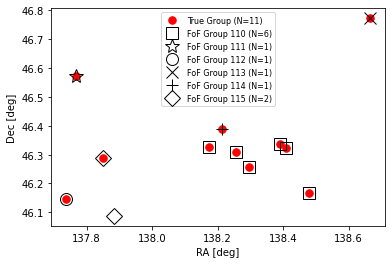

In [34]:
plt.figure()
sel=mock.haloid==1957371
plt.plot(mock[sel].ra, mock[sel].dec, 'r.', markersize=15, label='True Group (N=11)')
sel=mock.groupid==110
plt.plot(mock[sel].ra, mock[sel].dec, 's', markersize=12, markeredgecolor='k', markerfacecolor='None', label='FoF Group 110 (N=6)')
sel=mock.groupid==111
plt.plot(mock[sel].ra, mock[sel].dec, '*', markersize=15, markeredgecolor='k', markerfacecolor='None', label='FoF Group 111 (N=1)')
sel=mock.groupid==112
plt.plot(mock[sel].ra, mock[sel].dec, 'o', markersize=12, markeredgecolor='k', markerfacecolor='None', label='FoF Group 112 (N=1)')
sel=mock.groupid==113
plt.plot(mock[sel].ra, mock[sel].dec, 'x', markersize=12, markeredgecolor='k', markerfacecolor='None', label='FoF Group 113 (N=1)')
sel=mock.groupid==114
plt.plot(mock[sel].ra, mock[sel].dec, '+', markersize=12, markeredgecolor='k', markerfacecolor='None', label='FoF Group 114 (N=1)')
sel=mock.groupid==115
plt.plot(mock[sel].ra, mock[sel].dec, 'D', markersize=12, markeredgecolor='k', markerfacecolor='None', label='FoF Group 115 (N=2)')
plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.legend(loc='upper center',fontsize=8)
plt.show()

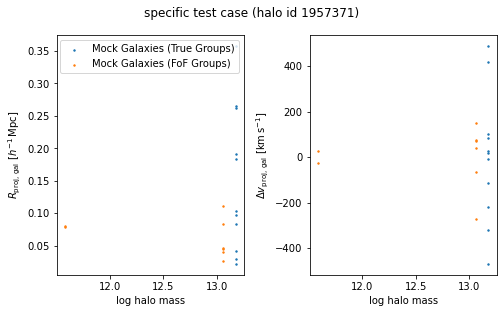

In [35]:
fig,(ax,ax1)=plt.subplots(ncols=2,figsize=doublecolsize)

sel = (mock.haloid==1957371)
ax.scatter(mock.loghalom[sel], mock.mockrprojgal[sel],s=2, label='Mock Galaxies (True Groups)')

sel = (eco.groupid>=110)&(eco.groupid<=115)
ax.scatter(eco.logmh[sel], eco.ecorprojgal[sel], s=2, label='Mock Galaxies (FoF Groups)')


ax.set_ylabel(r"$R_{\rm proj,\, gal}$ [$h^{-1}\rm\, Mpc$]")
ax.set_xlabel("log halo mass")

###########

sel = (mock.haloid==1957371)
ax1.scatter(mock.loghalom[sel], mock.mockvprojgal[sel],s=2, label='Mock Galaxies (True Groups)')

sel = (eco.groupid>=110)&(eco.groupid<=115)
ax1.scatter(eco.logmh[sel], eco.ecovprojgal[sel], s=2, label='Mock Galaxies (FoF Groups)')

ax1.set_ylabel(r"$\Delta v_{\rm proj,\, gal}$ [$\rm km\, s^{-1}$]")
ax1.set_xlabel("log halo mass")

plt.suptitle('specific test case (halo id 1957371)')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

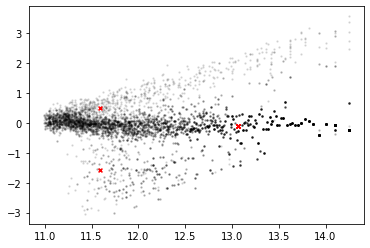

In [36]:
plt.figure()
sel = (eco.groupid>=110)&(eco.groupid<=115)
plt.scatter(eco.logmh, eco.logmh-eco.loghalom, s=2,color='k',alpha=0.1)
plt.scatter(eco.logmh[sel], eco.logmh[sel]-eco.loghalom[sel], s=15,marker='x',color='r')
plt.show()

### group 31 - perfect recovery of N=2 group

In [37]:
sel = (eco.logmh<11.5)&(eco.logmh>11.3)
eco[sel].groupid

47         31
48         31
129        96
130        96
131        96
         ... 
12832    7965
12833    7965
12842    7973
12843    7973
12869    7954
Name: groupid, Length: 741, dtype: int64

In [38]:
eco[eco.groupid==31][['M_group','loghalom','halo_ngal','g_ngal','haloid','ecorprojgal']]

,M_group,loghalom,halo_ngal,g_ngal,haloid,ecorprojgal
47,11.579921,11.692,2,2,1938745,0.010955
48,11.579921,11.692,2,2,1938745,0.010897


In [39]:
mock[mock.haloid==1938745][['M_group','loghalom','halo_ngal','g_ngal','haloid','groupid','cz','mockrprojgal']]#'ecorprojgal']]

,M_group,loghalom,halo_ngal,g_ngal,haloid,groupid,cz,mockrprojgal
47,11.579921,11.692,2,2,1938745,31,3778.786607,0.010955
48,11.579921,11.692,2,2,1938745,31,3819.021372,0.010897


In [40]:
eco[eco.groupid==7973][['M_group','loghalom','halo_ngal','g_ngal','haloid','ecorprojgal']]

,M_group,loghalom,halo_ngal,g_ngal,haloid,ecorprojgal
12842,11.553431,11.312,2,2,2538780,0.035950
12843,11.553431,11.312,2,2,2538780,0.035907


In [41]:
mock[mock.haloid==2538780][['M_group','loghalom','halo_ngal','g_ngal','haloid','groupid','cz','mockrprojgal']]#'ecorprojgal']]

,M_group,loghalom,halo_ngal,g_ngal,haloid,groupid,cz,mockrprojgal
12842,11.553431,11.312,2,2,2538780,7973,7306.654264,0.035950
12843,11.553431,11.312,2,2,2538780,7973,7323.836934,0.035907


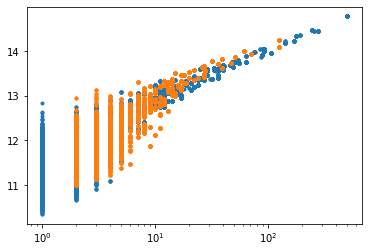

In [42]:
plt.figure()
plt.plot(mock.halo_ngal, mock.loghalom, '.')
plt.plot(eco.g_ngal, eco.logmh, '.')
plt.xscale('log')
plt.show()

# Realistic scatter in central-halo relations?

In [43]:
H0value=100.
mocks=[]
for ii in range(2,3): # mock with closest density is number 2
    tmp = pd.read_hdf("./halobiasmocks/fiducial/ECO_cat_{}_Planck_memb_cat.hdf5".format(ii))
    grpradeg,grpdedeg,grpcz = fof.group_skycoords(np.array(tmp.ra),np.array(tmp.dec),np.array(tmp.cz),np.array(tmp.haloid))
    half_angle = fof.angular_separation(tmp.ra, tmp.dec, grpradeg, grpdedeg)/2.
    tmp.loc[:,'mockrprojgal']=(tmp.cz+grpcz)/H0value * np.sin(half_angle)
    tmp.loc[:,'mockvprojgal']=(tmp.cz-grpcz)
    #tmp = tmp[(tmp.M_r<-17.33)&(grpcz>3000)&(grpcz<7000)&(tmp.halo_ngal>1)]
    mocks.append(tmp)
mock = pd.concat(mocks)
mock = mock[mock.cs_flag==1]
mock.loc[:,'loghalom']=mock.loghalom - np.log10(0.7)
print(len(mock))
totalvolumemocks = 192351.*len(mocks)

7929


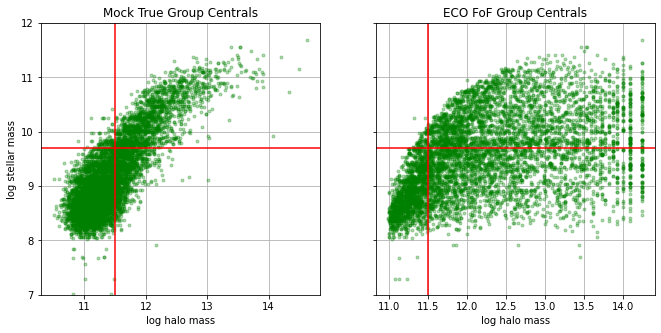

In [44]:
fig,axs=plt.subplots(ncols=2,sharey=True,figsize=(11,5))
axs[0].plot(mock.loghalom, mock.logmstar, 'g.',alpha=0.3)
axs[1].plot(eco.logmh, eco.logmstar, 'g.',alpha=0.3)

axs[0].axhline(9.7, color='red')
axs[1].axhline(9.7, color='red')
axs[0].axvline(11.5, color='red')
axs[1].axvline(11.5, color='red')

axs[0].set_title("Mock True Group Centrals")
axs[1].set_title("ECO FoF Group Centrals")
axs[0].set_ylim(7,12)
axs[0].set_ylabel("log stellar mass")
axs[0].set_xlabel("log halo mass")
axs[1].set_xlabel("log halo mass")
axs[0].grid()
axs[1].grid()
plt.show()

In [45]:
H0value=100.
mocks=[]
for ii in range(0,1): # mock with closest density is number 2
    tmp = pd.read_hdf("./halobiasmocks/fiducial/ECO_cat_{}_Planck_memb_cat.hdf5".format(ii))
    grpradeg,grpdedeg,grpcz = fof.group_skycoords(np.array(tmp.ra),np.array(tmp.dec),np.array(tmp.cz),np.array(tmp.haloid))
    half_angle = fof.angular_separation(tmp.ra, tmp.dec, grpradeg, grpdedeg)/2.
    tmp.loc[:,'mockrprojgal']=(tmp.cz+grpcz)/H0value * np.sin(half_angle)
    tmp.loc[:,'mockvprojgal']=(tmp.cz-grpcz)
    #tmp = tmp[(tmp.M_r<-17.33)&(grpcz>3000)&(grpcz<7000)&(tmp.halo_ngal>1)]
    mocks.append(tmp)
mock = pd.concat(mocks)
mock = mock[mock.g_galtype==1]
print(len(mock))
totalvolumemocks = 192351.*len(mocks)

9879


In [46]:
H0value=70.
eco = pd.read_csv("../g3groups/ECOliving_071122.csv")
eco = eco[(eco.absrmag<-17.33)&(eco.grpcz<7000)&(eco.grpcz>3000)]
grpradeg,grpdedeg,grpcz = fof.group_skycoords(np.array(eco.radeg),np.array(eco.dedeg),np.array(eco.cz),np.array(eco.grp))
half_angle = fof.angular_separation(eco.radeg,eco.dedeg,grpradeg,grpdedeg)/2.
eco.loc[:,'ecorprojgal']=(eco.cz+grpcz)/H0value * np.sin(half_angle)
eco.loc[:,'ecovprojgal']=np.abs(eco.cz-grpcz)
eco=eco[eco.fc==1]
#eco.loc[:,'logmh'] = eco['logmh']+np.log10(0.7)
print(len(eco))

6533


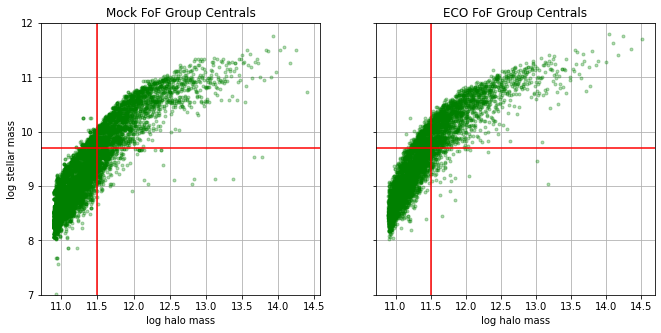

In [47]:
fig,axs=plt.subplots(ncols=2,sharey=True,figsize=(11,5))
axs[0].plot(mock.M_group, mock.logmstar, 'g.',alpha=0.3)
axs[1].plot(eco.logmh, eco.logmstar, 'g.',alpha=0.3)

axs[0].axhline(9.7, color='red')
axs[1].axhline(9.7, color='red')
axs[0].axvline(11.5, color='red')
axs[1].axvline(11.5, color='red')

axs[0].set_title("Mock FoF Group Centrals")
axs[1].set_title("ECO FoF Group Centrals")
axs[0].set_ylim(7,12)
axs[0].set_ylabel("log stellar mass")
axs[0].set_xlabel("log halo mass")
axs[1].set_xlabel("log halo mass")
axs[0].grid()
axs[1].grid()
plt.show()

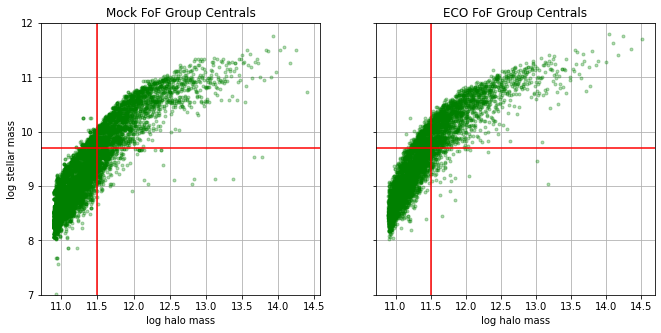

In [48]:
fig,axs=plt.subplots(ncols=2,sharey=True,figsize=(11,5))
axs[0].plot(mock.M_group, mock.logmstar, 'g.',alpha=0.3)
axs[1].plot(eco.logmh, eco.logmstar, 'g.',alpha=0.3)

axs[0].axhline(9.7, color='red')
axs[1].axhline(9.7, color='red')
axs[0].axvline(11.5, color='red')
axs[1].axvline(11.5, color='red')

axs[0].set_title("Mock FoF Group Centrals")
axs[1].set_title("ECO FoF Group Centrals")
axs[0].set_ylim(7,12)
axs[0].set_ylabel("log stellar mass")
axs[0].set_xlabel("log halo mass")
axs[1].set_xlabel("log halo mass")
axs[0].grid()
axs[1].grid()
plt.show()

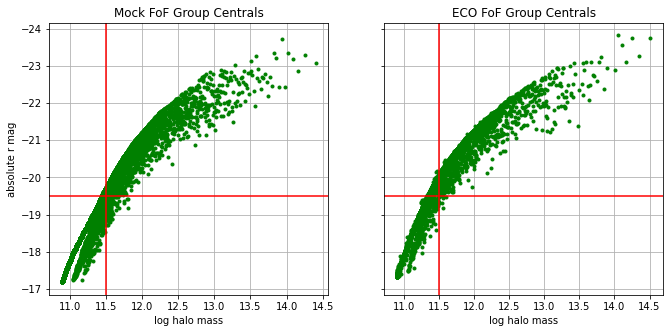

In [49]:
fig,axs=plt.subplots(ncols=2,sharey=True,figsize=(11,5))
axs[0].plot(mock.M_group, mock.M_r, 'g.')
axs[1].plot(eco.logmh, eco.absrmag, 'g.')

axs[0].axhline(-19.5, color='red')
axs[1].axhline(-19.5, color='red')
axs[0].axvline(11.5, color='red')
axs[1].axvline(11.5, color='red')

axs[0].set_title("Mock FoF Group Centrals")
axs[1].set_title("ECO FoF Group Centrals")
axs[0].set_ylabel("absolute r mag")
axs[0].set_xlabel("log halo mass")
axs[1].set_xlabel("log halo mass")
axs[0].grid()
axs[1].grid()

axs[0].invert_yaxis()

plt.show()

In [50]:
H0value=100.
mocks=[]
for ii in range(0,1): # mock with closest density is number 2
    tmp = pd.read_hdf("./halobiasmocks/fiducial/ECO_cat_{}_Planck_memb_cat.hdf5".format(ii))
    grpradeg,grpdedeg,grpcz = fof.group_skycoords(np.array(tmp.ra),np.array(tmp.dec),np.array(tmp.cz),np.array(tmp.haloid))
    half_angle = fof.angular_separation(tmp.ra, tmp.dec, grpradeg, grpdedeg)/2.
    tmp.loc[:,'mockrprojgal']=(tmp.cz+grpcz)/H0value * np.sin(half_angle)
    tmp.loc[:,'mockvprojgal']=(tmp.cz-grpcz)
    #tmp = tmp[(tmp.M_r<-17.33)&(grpcz>3000)&(grpcz<7000)&(tmp.halo_ngal>1)]
    mocks.append(tmp)
mock = pd.concat(mocks)
print(len(mock))
totalvolumemocks = 192351.*len(mocks)

15628


In [51]:
dwarfonlyhalos = mock.groupby('haloid').filter(lambda hh: (hh.M_r>-19.5).all())
gianthosting = mock.groupby('haloid').filter(lambda hh: (hh.M_r<-19.5).any())

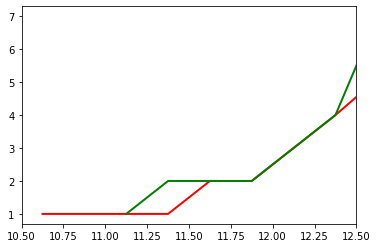

In [52]:
plt.figure()
binv = np.arange(10.5,13,0.25)
mediandwarfonlyN, binc, _, _ = cbs(dwarfonlyhalos.loghalom, dwarfonlyhalos.halo_ngal, 'median', bins=binv)
#plt.plot(binc,mediandwarfonlyN,'r',linewidth=3)
perc70dwarfonlyN, binc, _, _ = cbs(dwarfonlyhalos.loghalom, dwarfonlyhalos.halo_ngal, lambda x: np.nanpercentile(x,70), bins=binv)
plt.plot(binc,perc70dwarfonlyN, 'r-',linewidth=2)


mediangianthostN, _, _, _ = cbs(gianthosting.loghalom, gianthosting.halo_ngal, 'median', bins=binv)
#plt.plot(binc,mediangianthostN,'g-',linewidth=2)
perc70gianthostN, binc, _, _ = cbs(gianthosting.loghalom, gianthosting.halo_ngal, lambda x: np.nanpercentile(x,70), bins=binv)
plt.plot(binc,perc70gianthostN, 'g-',linewidth=2)
# plt.scatter(dwarfonlyhalos.loghalom, dwarfonlyhalos.halo_ngal, color='r', marker='*',s=2,alpha=0.1)
# plt.scatter(gianthosting.loghalom, gianthosting.halo_ngal, color='g', marker='*',s=2,alpha=0.1)
#plt.yscale('log')
plt.xlim(10.5,12.5)
plt.show()

In [56]:
mk = pd.read_hdf('./halobiasmocks/fiducial/ECO_cat_2_Planck_memb_cat.hdf5')
mk=mk[mk.cs_flag==1]

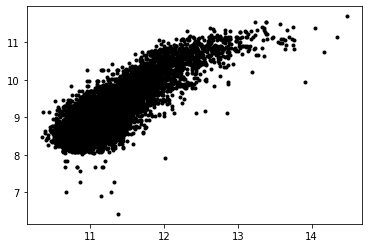

In [57]:
plt.figure()
plt.plot(mk.loghalom,mk.logmstar,'k.')
plt.show()